### Фокин Н. А. 5130901/30201

## Упражнения к главе 4.

### Упражнение 4.1

В ходе выполнения данного задания были получены спектры аудиозаписей звуков северного моря и сверчков:

In [62]:
import thinkdsp

D = 0.01

Функция для вывода белого, розового и броуновского шумов:

In [63]:
def plot_noise():
    thinkdsp.BrownianNoise().make_wave(duration=D, framerate=11025).make_spectrum().plot(label='Броуновский шум', alpha=0.5)
    thinkdsp.PinkNoise().make_wave(duration=D, framerate=11025).make_spectrum().plot(label='Розовый шум', alpha=0.5)
    thinkdsp.UncorrelatedUniformNoise().make_wave(duration=D, framerate=11025).make_spectrum().plot(label='Белый шум', alpha=0.5)

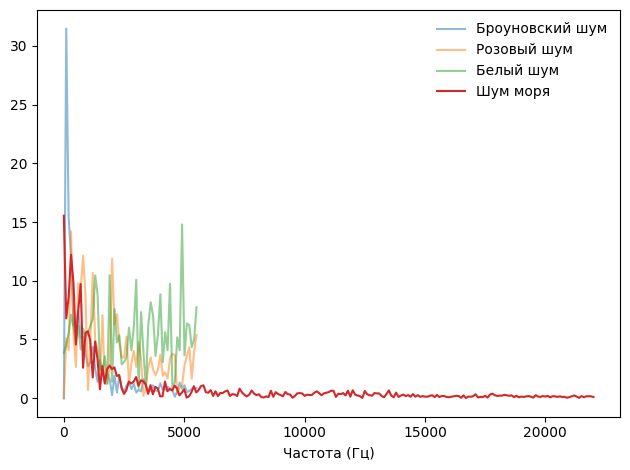

In [64]:
wave_sea = thinkdsp.read_wave('./ex1_wavs/sea.wav')
wave_crickets = thinkdsp.read_wave('./ex1_wavs/crickets.wav')

sp_sea = wave_sea.segment(start=2, duration=D).make_spectrum()
plot_noise()
sp_sea.plot(label='Шум моря')
thinkdsp.decorate(xlabel='Частота (Гц)')

По виду спектра шум моря больше всего похож на броуновский шум:

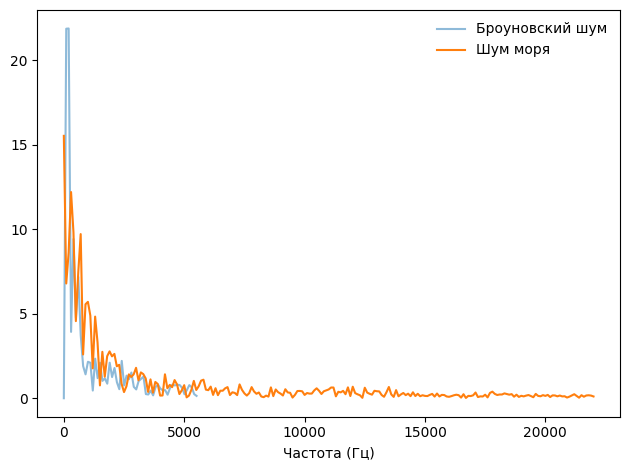

In [65]:
thinkdsp.BrownianNoise().make_wave(duration=D, framerate=11025).make_spectrum().plot(label='Броуновский шум', alpha=0.5)
sp_sea.plot(label='Шум моря')
thinkdsp.decorate(xlabel='Частота (Гц)')

Спектр мощности сигнала:

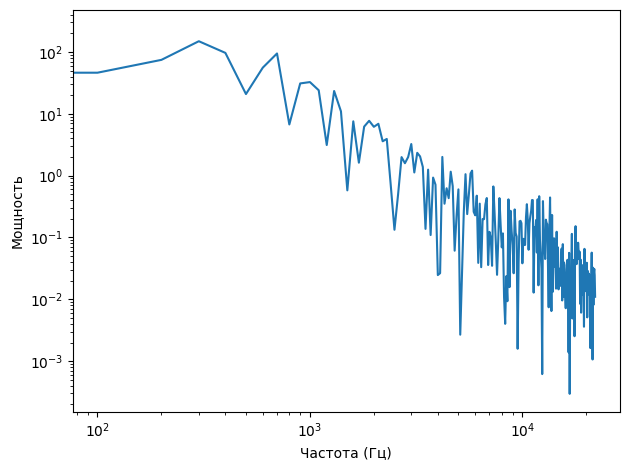

In [66]:
sp_sea.plot_power()

loglog = dict(xscale='log', yscale='log')
thinkdsp.decorate(xlabel='Частота (Гц)', ylabel='Мощность', **loglog)

Изменение во времени:

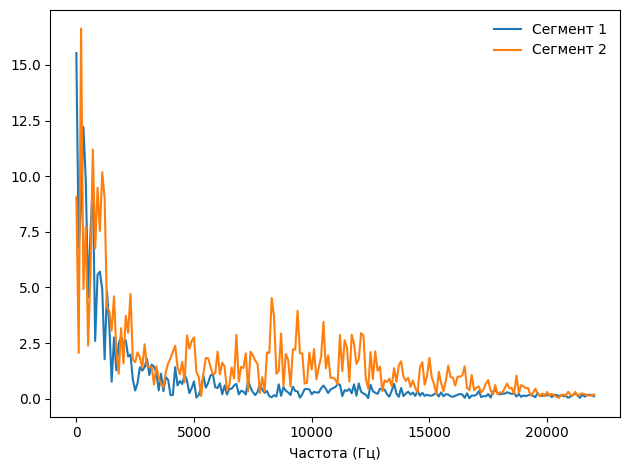

In [67]:
sp_sea2 = wave_sea.segment(start=5, duration=D).make_spectrum()
sp_sea.plot(label='Сегмент 1')
sp_sea2.plot(label='Сегмент 2')
thinkdsp.decorate(xlabel='Частота (Гц)')

Таким образом, амплитуда гармоник повысилась (особенно заметно на частотах от 5000 до 20000 Гц), но смешение частот осталось неизменным.

Теперь рассмотрим шум сверчков:

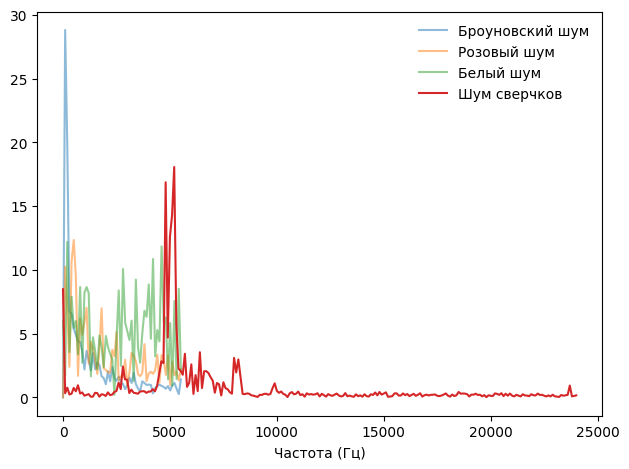

In [68]:
sp_crickets = wave_crickets.segment(start=2, duration=D).make_spectrum()
plot_noise()
sp_crickets.plot(label='Шум сверчков')
thinkdsp.decorate(xlabel='Частота (Гц)')

С учетом нахождения основной гармоники в области 5 кГц, трудно определить, на спектр какого шума похож спектр аудиозаписи сверчков. Однако амплитуда частот до 5кГц держится относительно постоянной (хоть она и меньше), как и у белого шума.

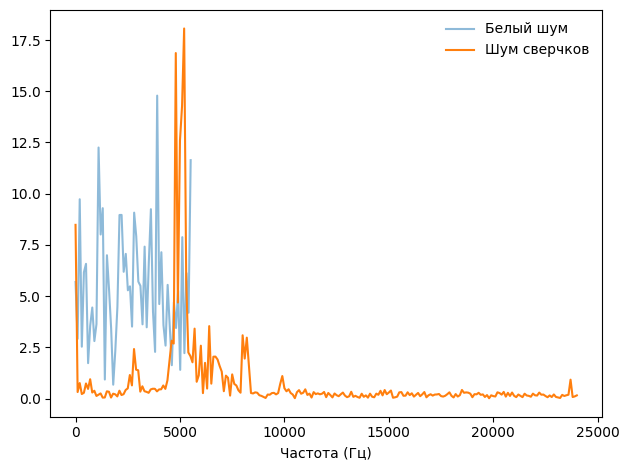

In [69]:
thinkdsp.UncorrelatedUniformNoise().make_wave(duration=D, framerate=11025).make_spectrum().plot(label='Белый шум', alpha=0.5)
sp_crickets.plot(label='Шум сверчков')
thinkdsp.decorate(xlabel='Частота (Гц)')

Спектр мощности сигнала:

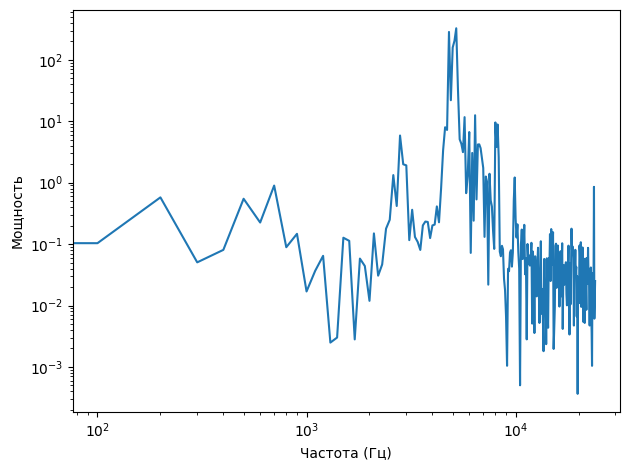

In [70]:
sp_crickets.plot_power()

loglog = dict(xscale='log', yscale='log')
thinkdsp.decorate(xlabel='Частота (Гц)', ylabel='Мощность', **loglog)

Измненение во времени:

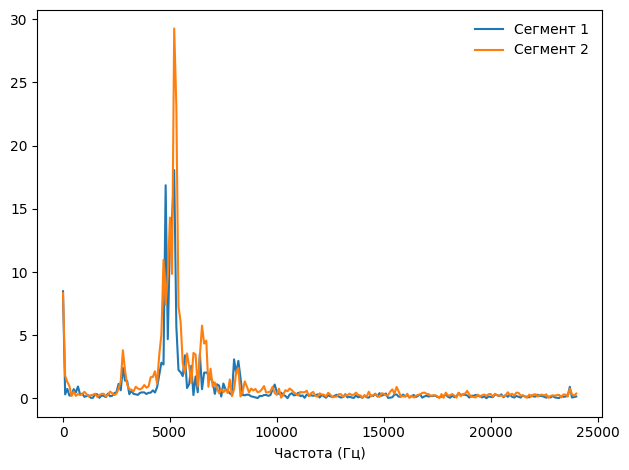

In [71]:
sp_crickets2 = wave_crickets.segment(start=5, duration=D).make_spectrum()
sp_crickets.plot(label='Сегмент 1')
sp_crickets2.plot(label='Сегмент 2')
thinkdsp.decorate(xlabel='Частота (Гц)')

Таким образом, как и при анализе шума моря, заметно повышается амплитуда, но в большей степени для основных гармоник.

### Упражнение 4.2

В ходе выполнения данного упражнения был реализован метод Бартлетта:

In [72]:
import numpy as np

def bartlett(wave, seg_length=512, win_flag=True):
    spm = wave.make_spectrogram(seg_length, win_flag)
    sps = spm.spec_map.values()
    psds = [sp.power for sp in sps]
    hs = np.sqrt(sum(psds) / len(psds))
    fs = next(iter(sps)).fs
    sp = thinkdsp.Spectrum(hs, fs, wave.framerate)
    return sp

Рассмотрим сегменты шума моря:

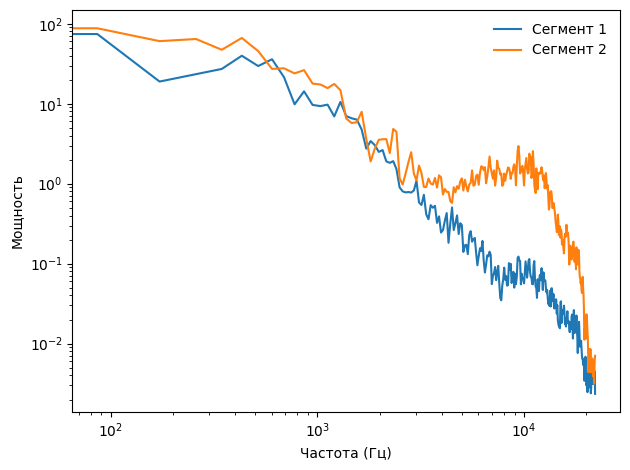

In [76]:
seg1 = wave_sea.segment(start=2, duration=D*10)
seg2 = wave_sea.segment(start=5, duration=D*10)

psd1 = bartlett(seg1)
psd2 = bartlett(seg2)

psd1.plot_power(label='Сегмент 1')
psd2.plot_power(label='Сегмент 2')

thinkdsp.decorate(xlabel='Частота (Гц)', ylabel='Мощность', **loglog)

Благодаря применению метода Бартлетта расхождения в амплитудах в от 5 до 20 кГц стали отчетливыми.

### Упражнение 4.3

Вычислим спектр цен BitCoin как функцию времени:

In [97]:
import pandas as pd

df = pd.read_csv('bitcoin (1).csv', parse_dates=[0])
df

,Дата,Значение
0,2026-02-15,70263.651358
1,2026-02-14,69953.996932
2,2026-02-13,68799.130019
3,2026-02-12,65324.263438
4,2026-02-11,67579.182312
...,...,...
347,2025-02-19,95847.003032
348,2025-02-18,93929.608871
349,2025-02-17,96041.991564
350,2025-02-16,97016.421047


In [98]:
ys = df['Значение']
ts = df.index

Спектр:

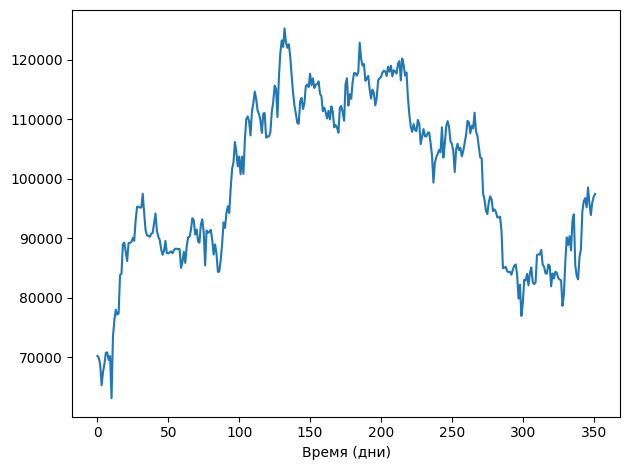

In [99]:
wave = thinkdsp.Wave(ys, ts, framerate=1)
wave.plot()
thinkdsp.decorate(xlabel='Время (дни)')

Спектр мощности:

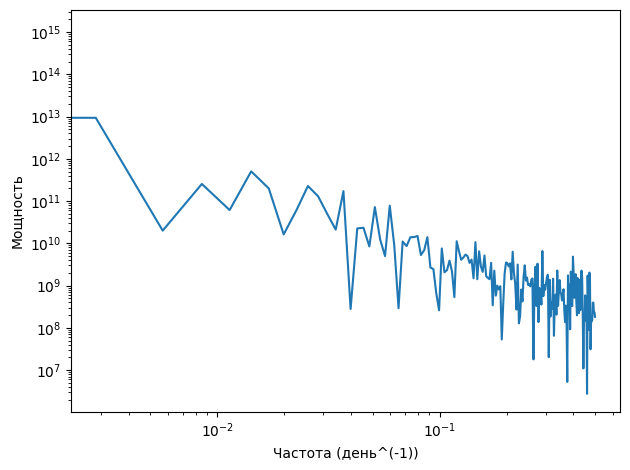

In [100]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
thinkdsp.decorate(xlabel='Частота (день^(-1))', ylabel='Мощность', **loglog)

In [101]:
spectrum.estimate_slope()[0]

np.float64(-1.702527034384414)

Угловые коэффициенты шумов:

In [103]:
thinkdsp.UncorrelatedUniformNoise().make_wave(duration=350, framerate=1100).make_spectrum().estimate_slope()[0]

np.float64(-0.005692454445858964)

In [104]:
thinkdsp.PinkNoise().make_wave(duration=350, framerate=1100).make_spectrum().estimate_slope()[0]

np.float64(-0.9970133623762384)

In [105]:
thinkdsp.BrownianNoise().make_wave(duration=350, framerate=1100).make_spectrum().estimate_slope()[0]

np.float64(-1.8033511601339585)

Угловой коэффициент спектра биткоина в большей степени соответсвует угловому коэффициенту спектра Броуновского шума.

### Упражнение 4.4

В ходе выполнения данного задания был создан класс, моделирующий выход счетчика Гейгера в определенный момент времени.

In [107]:
class UncorrelatedPoissonNoise(thinkdsp.Noise):
    def evaluate(self, ts):
        ys = np.random.poisson(self.amp, len(ts))
        return ys

Создадим сигнал с невысоким значением среднего числа частиц за время каждого интервала:

In [111]:
up = UncorrelatedPoissonNoise(amp=0.001).make_wave(duration=1)
up.make_audio()

Полученный звук действительно иммитирует аудиосигнал счетчика Гейгера. Теперь увеличим это значение до 10:

In [112]:
up = UncorrelatedPoissonNoise(amp=10).make_wave(duration=1)
up.make_audio()

Получаем сигнал, похожий на белый шум. Проверим это с помощью спектра мощности:

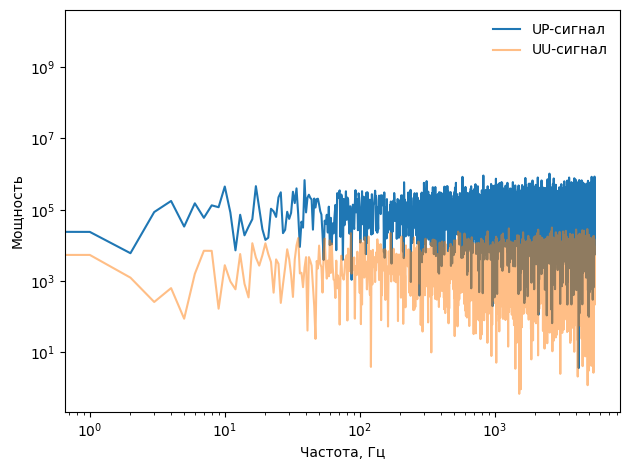

In [113]:
up.make_spectrum().plot_power(label='UP-сигнал')
thinkdsp.UncorrelatedUniformNoise().make_wave(duration=1).make_spectrum().plot_power(label='UU-сигнал', alpha=0.5)
thinkdsp.decorate(xlabel='Частота, Гц', ylabel='Мощность', **loglog)

Таким образом, при больших значениях am получаем сигнал, спектр мощности которого почти один в один повторяет спектр мощности белого шума, но с бóльшими значениями амплитуды.

### Упражнение 4.5

Рассмотрим более эффективный вариант генерации розового шума - алгоритм Voss-McCartney.

In [116]:
class VossMcCartneyPinkNoise:
    def __init__(self, num_octaves=16, scale=1.0):
        self.num_octaves = num_octaves
        self.scale = scale
        self.values = [np.random.uniform(-1, 1) for _ in range(num_octaves)]
        self.step = 0
    
    def next_sample(self):
        sample = 0.0
        for i in range(self.num_octaves):
            period = 1 << i
            if self.step % period == 0:
                self.values[i] = np.random.uniform(-1, 1)
            sample += self.values[i]
        
        self.step += 1
        return sample * self.scale
    
    def generate(self, n_samples):
        return [self.next_sample() for _ in range(n_samples)]


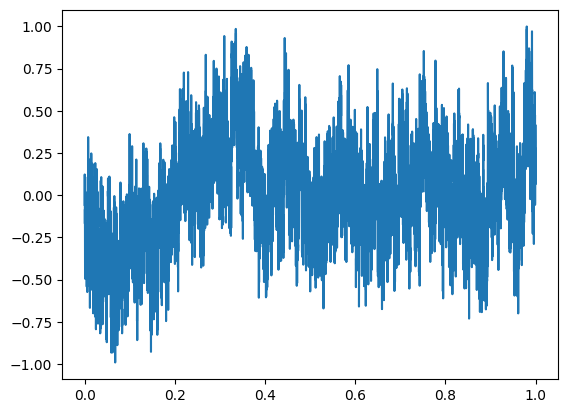

In [123]:
ys = VossMcCartneyPinkNoise(num_octaves=16, scale=0.1).generate(11025)
wave = thinkdsp.Wave(ys)
wave.unbias()
wave.normalize()
wave.plot()

Проверим соответсвие спектра этого сигнала спектру розового шума:

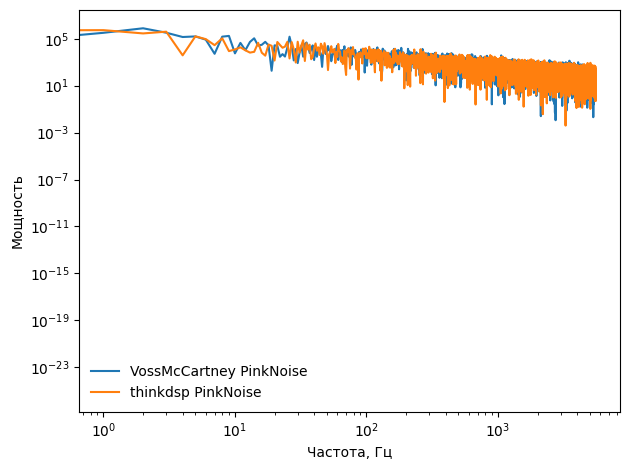

In [129]:
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
spectrum.plot_power(label='VossMcCartney PinkNoise')
pn_sp = thinkdsp.PinkNoise().make_wave(duration=1, framerate=11025).make_spectrum()
pn_sp.plot_power(label='thinkdsp PinkNoise')
thinkdsp.decorate(xlabel='Частота, Гц', ylabel='Мощность', **loglog)

Проверим угловые коэффициенты:

In [133]:
spectrum.estimate_slope()[0]

np.float64(-1.0606582657953048)

In [134]:
pn_sp.estimate_slope()[0]

np.float64(-1.019982858471877)

Таким образом, получаем розовый шум, оценка углового коэффициента которого близка к 1.